In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from aidsorb.data import get_names
import numpy as np
from retnext.transforms import ClipScaleVoxels
import torch

In [3]:
!pwd

/home/asarikas/projects/intellipore/notebooks


## Pretraining summary

In [4]:
with open('../experiments/pretrain/early_pretrain/test_results.json') as fhand:
    db_tasks_dict = json.load(fhand)

In [5]:
total = 0
for db, tasks  in db_tasks_dict.items():
    total += len(tasks)
    print(db, len(tasks))

print(total)

hCOF 11
hMOF 31
Tob 21
UO 24
C19 34
121


In [6]:
# Train/val sizes
total = 0
for db, name in zip(
    ['MOFXDB_hMOF', 'MOFXDB_Tobacco', 'MOFXDB_CoRE2019', 'UO', 'hCOF'],
    ['hMOF', 'Tob', 'C19', 'UO', 'hCOF']
):
    #total += len(get_names(f'../data/{db}/validation.json'))
    labels = len(db_tasks_dict[name].keys()) * len(get_names(f'../data/{db}/train.json'))
    total += labels
    print(db, f'{labels:_}')
    #print(db, len(get_names(f'../data/{db}/validation.json')))

print(f'{total:_}')

MOFXDB_hMOF 3_753_976
MOFXDB_Tobacco 254_877
MOFXDB_CoRE2019 331_024
UO 7_516_296
hCOF 716_386
12_572_559


In [7]:
len(db_tasks_dict['hMOF'])

31

## Porosity distribution

In [8]:
df_dict = {}

#for db in ['MOFXDB_hMOF', 'MOFXDB_Tobacco', 'MOFXDB_CoRE2019', 'UO', 'hCOF', 'NU-topoMOF-2025']:
for db in ['MOFXDB_hMOF', 'MOFXDB_Tobacco', 'MOFXDB_CoRE2019', 'UO', 'hCOF']:
    df_dict[db] = pd.read_csv(f'../data/{db}/clean.csv', index_col='name')

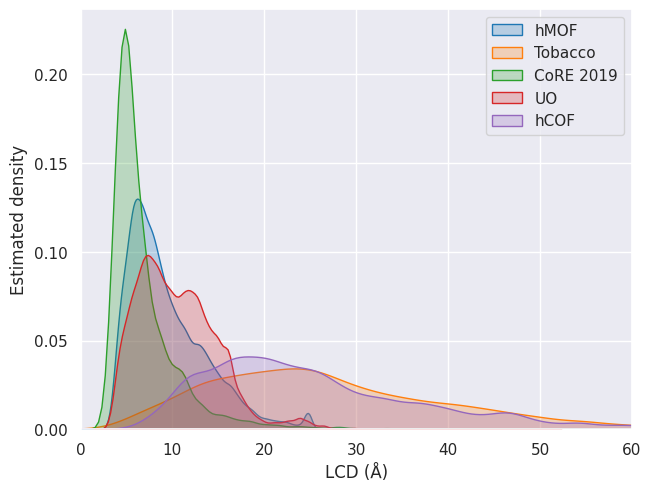

In [9]:
sns.set_theme()
sns.set_palette('tab10')

fig, ax = plt.subplots(layout='constrained')

sns.kdeplot(df_dict['MOFXDB_hMOF']['lcd'], label='hMOF', ax=ax, fill=True)
sns.kdeplot(df_dict['MOFXDB_Tobacco']['lcd'], label='Tobacco', ax=ax, fill=True)
sns.kdeplot(df_dict['MOFXDB_CoRE2019']['lcd'], label='CoRE 2019', ax=ax, fill=True)
sns.kdeplot(df_dict['UO']['largest_included_sphere_diameter [A]'], label='UO', ax=ax, fill=True)
sns.kdeplot(df_dict['hCOF']['largest included sphere diameter [A]'], label='hCOF', ax=ax, fill=True)
#sns.kdeplot(df_dict['NU-topoMOF-2025']['LCD'], label='NU25', ax=ax, fill=True)

ax.set_xlabel('LCD (Å)')
ax.set_ylabel('Estimated density')
ax.set_xlim(0, 60)
#ax.set_title('Distribution of pretraining databases')
ax.legend()
#plt.savefig('figures/lcd.pdf', bbox_inches='tight', pad_inches=0.)
plt.savefig('figures/lcd.pdf')

In [ ]:
fig, ax = plt.subplots(layout='constrained')

sns.kdeplot(df_dict['MOFXDB_hMOF']['void_fraction'], label='hMOF', ax=ax, fill=True)
sns.kdeplot(df_dict['MOFXDB_Tobacco']['void_fraction'], label='Tobacco', ax=ax, fill=True)
sns.kdeplot(df_dict['MOFXDB_CoRE2019']['void_fraction'], label='CoRE 2019', ax=ax, fill=True)
sns.kdeplot(df_dict['UO']['void_fraction'], label='UO', ax=ax, fill=True)
sns.kdeplot(df_dict['hCOF']['void fraction [widom]'], label='hCOF', ax=ax, fill=True)

ax.set_xlabel('Void fraction')
ax.set_ylabel('Estimated density')
ax.set_xlim(0, 1)
#ax.set_title('Distribution of pretraining databases')
ax.legend()

#plt.savefig('figures/vf.pdf', bbox_inches='tight', pad_inches=0.)
plt.savefig('figures/vf.pdf')

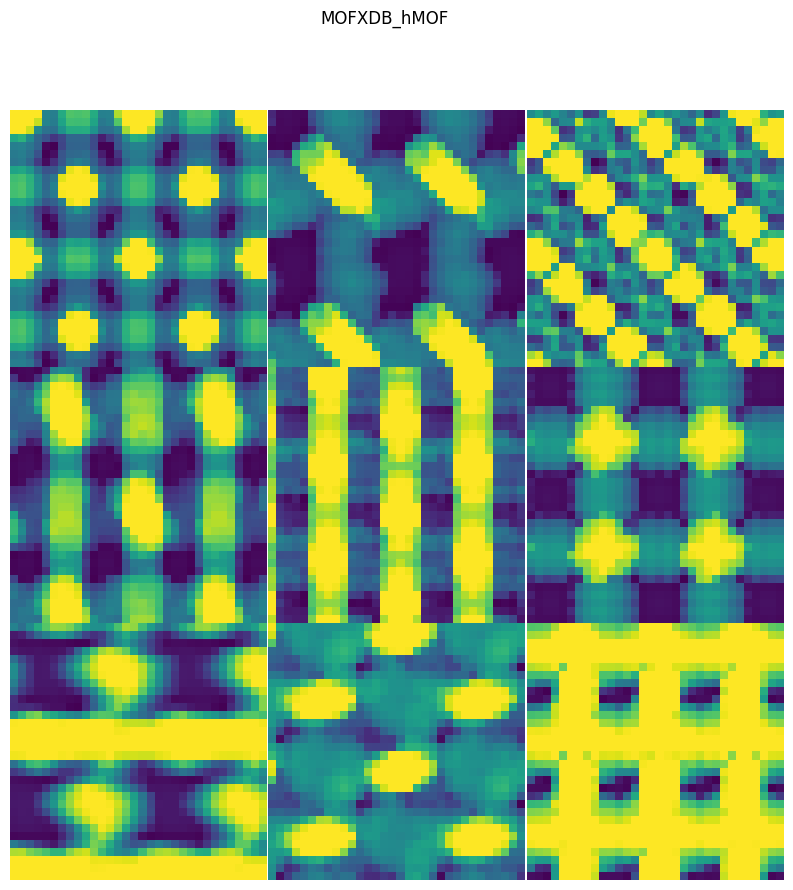

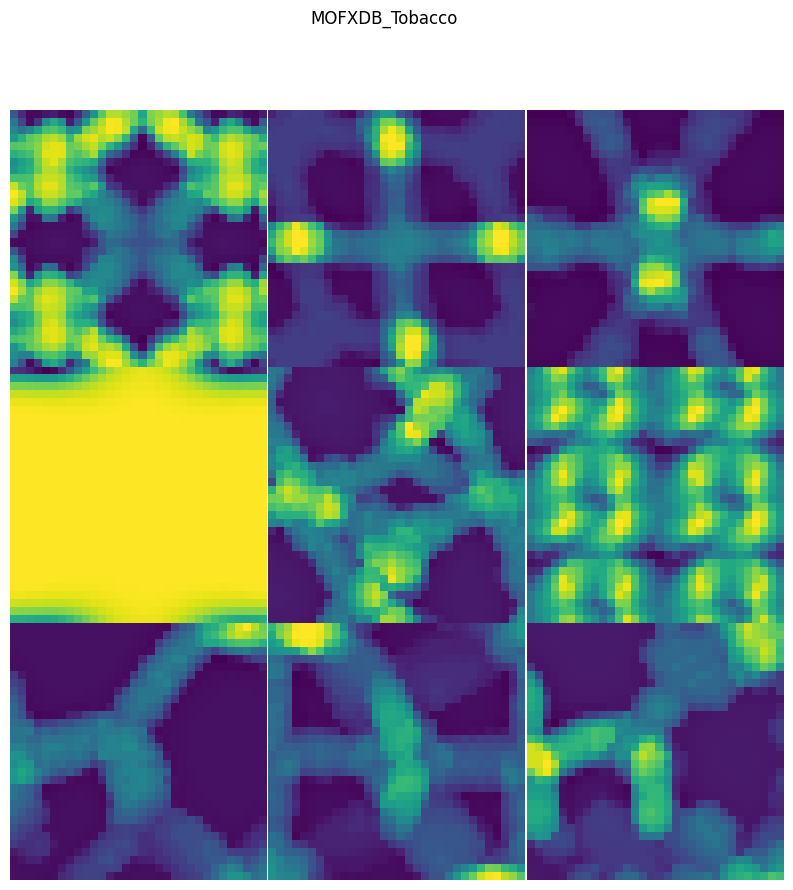

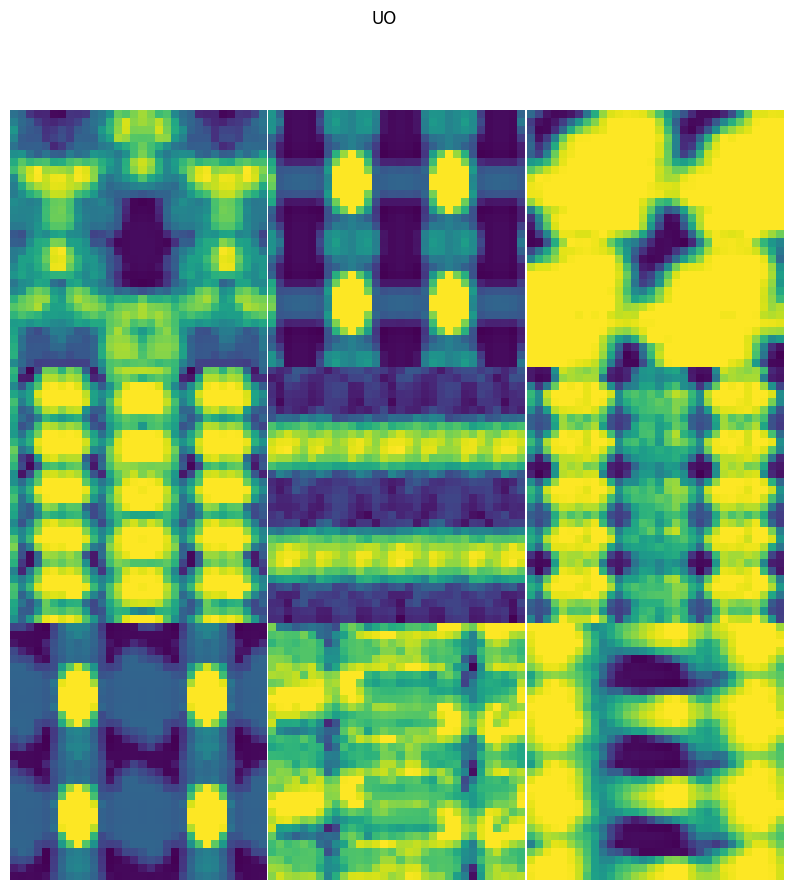

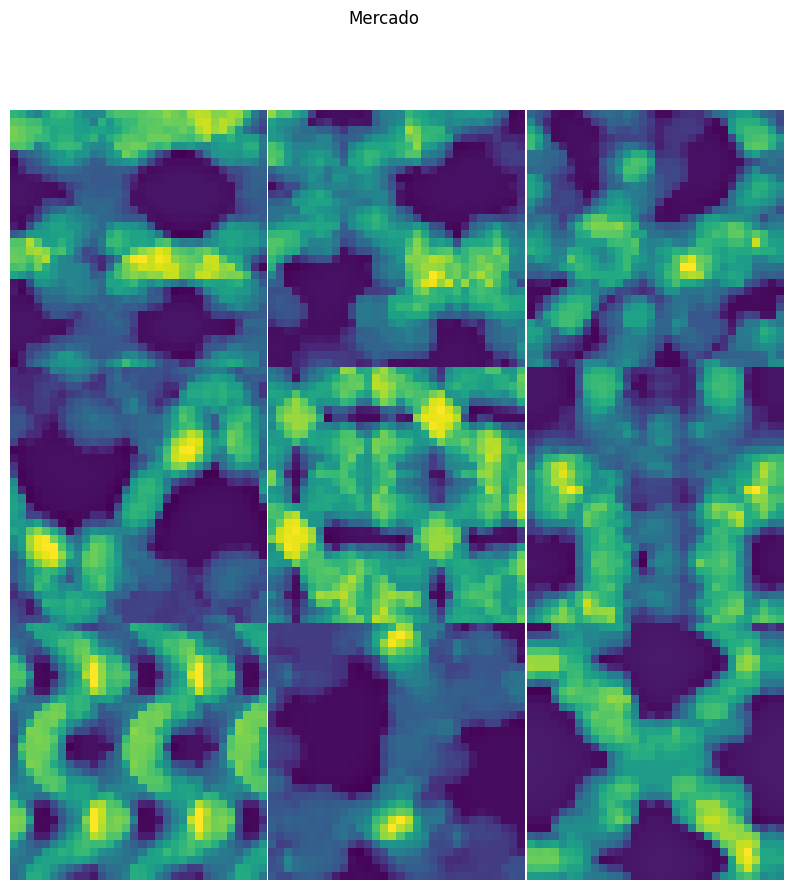

In [148]:
for db in ['MOFXDB_hMOF', 'MOFXDB_Tobacco', 'UO', 'Mercado']:
    fig, axes = plt.subplots(3, 3, figsize=[10, 10])
    images = np.array([
        ClipScaleVoxels()(torch.from_numpy(np.load(f'../data/{db}/voxels_data/{name}.npy'))).numpy()
        for name in get_names(f'../data/{db}/train.json')[300:500]
    ])

    for i, (ax, img) in enumerate(zip(axes.flat, images)):
        #ax.imshow(images.std(0)[i], interpolation='gaussian')
        ax.imshow(img.mean(0))
        #ax.imshow(img[0])
        ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(db)
    fig.subplots_adjust(wspace=0.0, hspace=0.0)

    #plt.savefig(f'../figures/{db}_collage.png', dpi=300, bbox_inches='tight', pad_inches=0)